# import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
%matplotlib inline

#  Read Data

In [2]:
# read data
weather= pd.read_csv("data/weather_burbank_airport.csv")
charging=pd.read_csv("data/charging_sessions.csv")
weather.head(10)

,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature
0,Burbank,2018-01-01 08:53:00,9.0,33.0,Fair,991.75,9.0,0.0,8.0
1,Burbank,2018-01-01 09:53:00,9.0,33.0,Fair,992.08,0.0,0.0,9.0
2,Burbank,2018-01-01 10:53:00,9.0,21.0,Haze,992.08,0.0,0.0,9.0
3,Burbank,2018-01-01 11:53:00,9.0,29.0,Partly Cloudy,992.08,0.0,0.0,9.0
4,Burbank,2018-01-01 12:53:00,8.0,33.0,Fair,992.08,0.0,0.0,8.0
5,Burbank,2018-01-01 13:53:00,8.0,33.0,Fair,992.08,0.0,0.0,8.0
6,Burbank,2018-01-01 14:53:00,7.0,30.0,Partly Cloudy,992.08,0.0,0.0,7.0
7,Burbank,2018-01-01 15:53:00,8.0,34.0,Fair,992.41,0.0,0.0,8.0
8,Burbank,2018-01-01 16:53:00,12.0,34.0,Fair,993.39,0.0,0.0,12.0
9,Burbank,2018-01-01 17:53:00,16.0,34.0,Fair,994.05,0.0,0.0,16.0


## check the weather dataset

In [3]:
weather.info()
# The columns of temperature,cloud_cover,cloud_cover_description,pressure, windspeed and felt_temperature have missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29244 entries, 0 to 29243
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city                     29244 non-null  object 
 1   timestamp                29244 non-null  object 
 2   temperature              29219 non-null  float64
 3   cloud_cover              29224 non-null  float64
 4   cloud_cover_description  29224 non-null  object 
 5   pressure                 29236 non-null  float64
 6   windspeed                29158 non-null  float64
 7   precipitation            29244 non-null  float64
 8   felt_temperature         29218 non-null  float64
dtypes: float64(6), object(3)
memory usage: 2.0+ MB


### fill in the missing values

In [4]:
def missing(df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum() / df.isnull().count()).sort_values(ascending=False)
    missing_values = pd.concat([missing_number, missing_percent], axis=1,keys=['missing_number','missing_percent'])
    total_missing_number=missing_number.sum()
    total_missing_percent=missing_percent.sum()
    total_row=pd.DataFrame([[total_missing_number,total_missing_percent]],
                           columns=['missing_number','missing_percent'],
                           index=['total'])
    missing_values=pd.concat([missing_values,total_row])
    return missing_values
# Define a function to show the number and percentage of missing values for each column, as well as the total number of missing values in the entire dataset.

In [5]:
missing(weather)
# filter out columns like ‘City’ ‘Precipitation’ and ‘Timestamp’ (no null values)

,missing_number,missing_percent
windspeed,86,0.002941
felt_temperature,26,0.000889
temperature,25,0.000855
cloud_cover,20,0.000684
cloud_cover_description,20,0.000684
pressure,8,0.000274
city,0,0.000000
timestamp,0,0.000000
precipitation,0,0.000000
total,185,0.006326


In [6]:
weather_filling=weather.drop(['timestamp','city','precipitation','cloud_cover_description'], axis=1)
print(weather_filling)
### Delete columns with no missing values and non-numeric columns.

       temperature  cloud_cover  pressure  windspeed  felt_temperature
0              9.0         33.0    991.75        9.0               8.0
1              9.0         33.0    992.08        0.0               9.0
2              9.0         21.0    992.08        0.0               9.0
3              9.0         29.0    992.08        0.0               9.0
4              8.0         33.0    992.08        0.0               8.0
...            ...          ...       ...        ...               ...
29239         13.0         33.0    986.81        0.0              13.0
29240         12.0         33.0    986.81       11.0              12.0
29241         12.0         33.0    987.47        9.0              12.0
29242         11.0         33.0    987.14       13.0              11.0
29243         10.0         33.0    987.80        6.0              10.0

[29244 rows x 5 columns]


In [7]:
### Fill missing values with the mean values from the three rows above and below in the same column
for col in weather_filling.columns:
        if weather_filling[col].isnull().any():
            rolling_mean=weather_filling[col].rolling(window=7,min_periods=1,center=True).mean()
            weather_filling[col]=weather_filling[col].fillna(rolling_mean)
missing(weather_filling)

,missing_number,missing_percent
temperature,0,0.0
cloud_cover,0,0.0
pressure,0,0.0
windspeed,0,0.0
felt_temperature,0,0.0
total,0,0.0


In [8]:
### update original weather data
weather.update(weather_filling)
missing(weather)

,missing_number,missing_percent
cloud_cover_description,20,0.000684
city,0,0.000000
timestamp,0,0.000000
temperature,0,0.000000
cloud_cover,0,0.000000
pressure,0,0.000000
windspeed,0,0.000000
precipitation,0,0.000000
felt_temperature,0,0.000000
total,20,0.000684


In [9]:
### fill non-numeric columns(cloud_cover_description)
weather['cloud_cover_description'] = weather['cloud_cover_description'].fillna(method='ffill')
missing(weather)

C:\Users\zp\AppData\Local\Temp\ipykernel_20592\1945171366.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  weather['cloud_cover_description'] = weather['cloud_cover_description'].fillna(method='ffill')


,missing_number,missing_percent
city,0,0.0
timestamp,0,0.0
temperature,0,0.0
cloud_cover,0,0.0
cloud_cover_description,0,0.0
pressure,0,0.0
windspeed,0,0.0
precipitation,0,0.0
felt_temperature,0,0.0
total,0,0.0


### Check for duplicates

In [10]:
weather.drop_duplicates
#### No duplicate data

<bound method DataFrame.drop_duplicates of           city            timestamp  temperature  cloud_cover  \
0      Burbank  2018-01-01 08:53:00          9.0         33.0   
1      Burbank  2018-01-01 09:53:00          9.0         33.0   
2      Burbank  2018-01-01 10:53:00          9.0         21.0   
3      Burbank  2018-01-01 11:53:00          9.0         29.0   
4      Burbank  2018-01-01 12:53:00          8.0         33.0   
...        ...                  ...          ...          ...   
29239  Burbank  2021-01-01 03:53:00         13.0         33.0   
29240  Burbank  2021-01-01 04:53:00         12.0         33.0   
29241  Burbank  2021-01-01 05:53:00         12.0         33.0   
29242  Burbank  2021-01-01 06:53:00         11.0         33.0   
29243  Burbank  2021-01-01 07:53:00         10.0         33.0   

      cloud_cover_description  pressure  windspeed  precipitation  \
0                        Fair    991.75        9.0            0.0   
1                        Fair    992.0

### Check for outlier

In [11]:
weather.describe()

,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature
count,29244.000000,29244.000000,29244.000000,29244.000000,29244.000000,29244.000000
mean,17.883031,30.109382,986.879276,8.571036,0.059360,17.728579
std,6.453591,5.399077,3.606671,6.694556,0.471682,6.320396
min,2.000000,4.000000,971.000000,0.000000,0.000000,0.000000
25%,13.000000,26.000000,984.500000,6.000000,0.000000,13.000000
50%,17.000000,33.000000,986.480000,7.000000,0.000000,17.000000
75%,22.000000,34.000000,989.110000,13.000000,0.000000,22.000000
max,46.000000,47.000000,999.650000,57.000000,18.540000,42.000000


In [12]:
#### Generate a boxplot for the specified column, extract the outliers
#### and calculate the unique values of the outliers along with their frequencies.
def plot_outliers(column):
    plt.figure()
    boxplot=weather[column].plot(kind='box',return_type='dict')
    x=boxplot['fliers'][0].get_xdata()
    y=boxplot['fliers'][0].get_ydata()
    unique_values, counts = np.unique(y, return_counts=True)
    for value, count in zip(unique_values, counts):
        print(f"Value: {value}, Count: {count}")
    plt.title(f"Boxplot of {column}")
    plt.show()

    

Value: 36.0, Count: 100
Value: 37.0, Count: 56
Value: 38.0, Count: 20
Value: 39.0, Count: 10
Value: 40.0, Count: 2
Value: 41.0, Count: 10
Value: 42.0, Count: 7
Value: 43.0, Count: 2
Value: 44.0, Count: 8
Value: 45.0, Count: 8
Value: 46.0, Count: 2


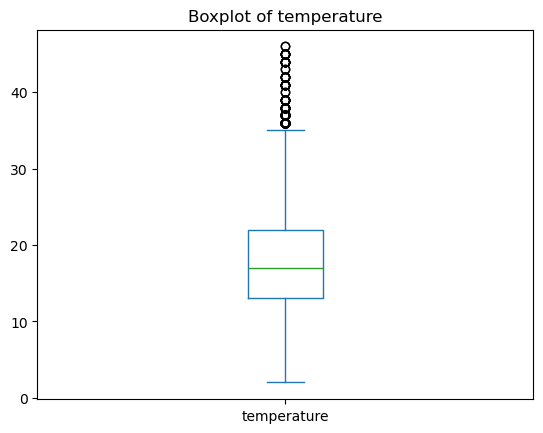

In [13]:
plot_outliers('temperature')

Value: 4.0, Count: 23
Value: 11.0, Count: 906
Value: 12.0, Count: 249
Value: 47.0, Count: 4


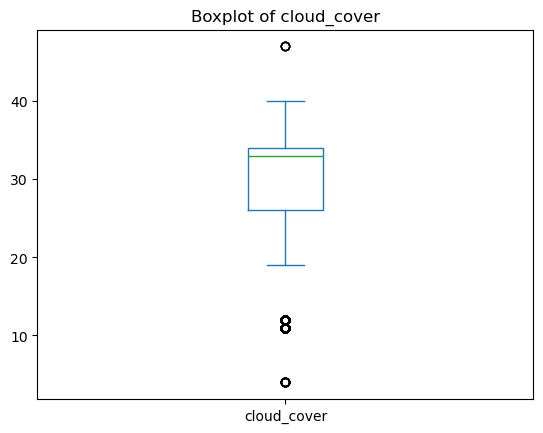

In [14]:
plot_outliers('cloud_cover')

Value: 971.0, Count: 2
Value: 971.33, Count: 2
Value: 971.66, Count: 4
Value: 971.99, Count: 2
Value: 972.32, Count: 3
Value: 972.65, Count: 3
Value: 972.98, Count: 1
Value: 973.31, Count: 13
Value: 973.64, Count: 11
Value: 973.97, Count: 11
Value: 974.3, Count: 10
Value: 974.63, Count: 12
Value: 974.95, Count: 10
Value: 975.28, Count: 12
Value: 975.61, Count: 19
Value: 975.94, Count: 9
Value: 976.27, Count: 14
Value: 976.6, Count: 11
Value: 976.93, Count: 18
Value: 977.26, Count: 7
Value: 996.03, Count: 60
Value: 996.36, Count: 56
Value: 996.69, Count: 47
Value: 997.02, Count: 34
Value: 997.34, Count: 17
Value: 997.67, Count: 21
Value: 998.0, Count: 18
Value: 998.33, Count: 15
Value: 998.66, Count: 10
Value: 998.99, Count: 5
Value: 999.32, Count: 2
Value: 999.65, Count: 5


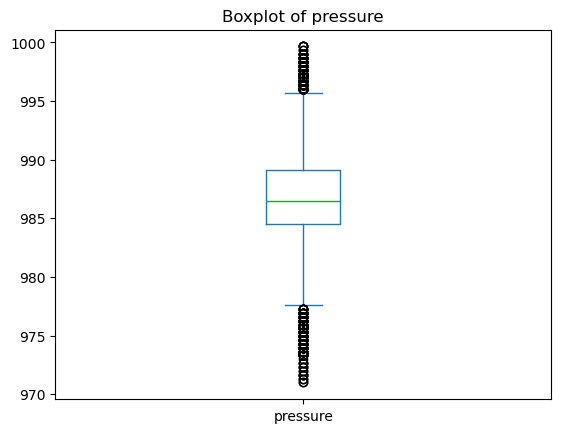

In [15]:
plot_outliers('pressure')

Value: 24.0, Count: 158
Value: 25.833333333333332, Count: 1
Value: 26.0, Count: 113
Value: 28.0, Count: 89
Value: 30.0, Count: 58
Value: 31.0, Count: 38
Value: 33.0, Count: 35
Value: 35.0, Count: 27
Value: 37.0, Count: 18
Value: 39.0, Count: 10
Value: 41.0, Count: 6
Value: 43.0, Count: 9
Value: 44.0, Count: 5
Value: 46.0, Count: 8
Value: 48.0, Count: 4
Value: 52.0, Count: 1
Value: 54.0, Count: 2
Value: 57.0, Count: 1


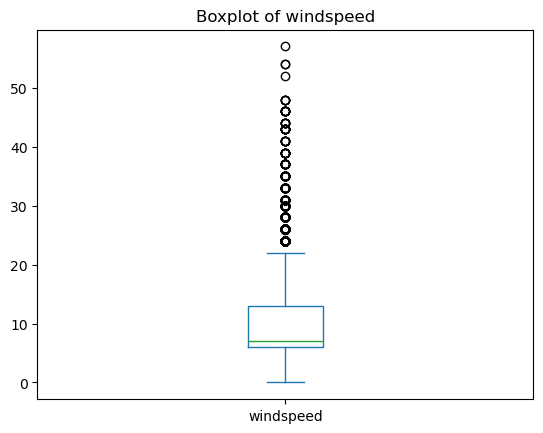

In [16]:
plot_outliers('windspeed')

Value: 0.25, Count: 313
Value: 0.51, Count: 158
Value: 0.76, Count: 125
Value: 1.02, Count: 86
Value: 1.27, Count: 80
Value: 1.52, Count: 59
Value: 1.78, Count: 50
Value: 2.03, Count: 31
Value: 2.29, Count: 32
Value: 2.54, Count: 33
Value: 2.79, Count: 23
Value: 3.05, Count: 11
Value: 3.3, Count: 20
Value: 3.56, Count: 12
Value: 3.81, Count: 7
Value: 4.06, Count: 6
Value: 4.32, Count: 15
Value: 4.57, Count: 9
Value: 4.83, Count: 9
Value: 5.08, Count: 13
Value: 5.33, Count: 8
Value: 5.59, Count: 4
Value: 5.84, Count: 4
Value: 6.1, Count: 4
Value: 6.35, Count: 2
Value: 6.6, Count: 2
Value: 6.86, Count: 6
Value: 7.11, Count: 1
Value: 7.37, Count: 3
Value: 7.62, Count: 3
Value: 7.87, Count: 2
Value: 8.13, Count: 2
Value: 8.38, Count: 1
Value: 8.64, Count: 2
Value: 9.91, Count: 3
Value: 10.67, Count: 1
Value: 10.92, Count: 1
Value: 11.18, Count: 1
Value: 11.43, Count: 1
Value: 12.45, Count: 1
Value: 12.7, Count: 1
Value: 13.97, Count: 1
Value: 18.54, Count: 1


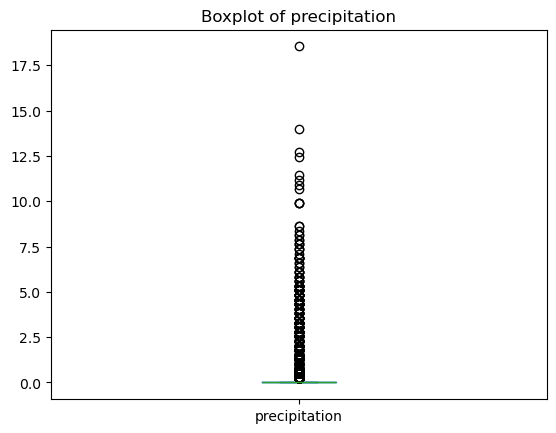

In [17]:
plot_outliers('precipitation')

Value: 36.0, Count: 38
Value: 37.0, Count: 21
Value: 38.0, Count: 13
Value: 39.0, Count: 11
Value: 40.0, Count: 6
Value: 41.0, Count: 13
Value: 42.0, Count: 6


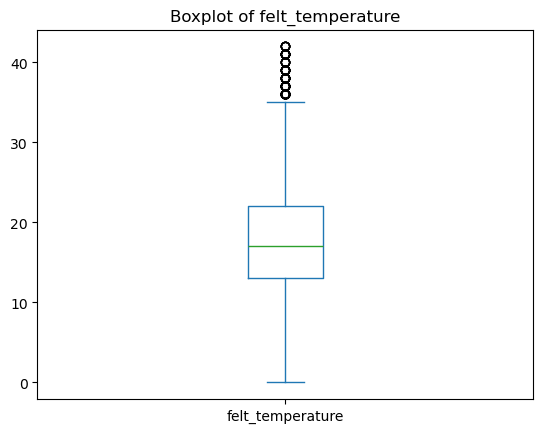

In [18]:
plot_outliers('felt_temperature')

##### I’m not sure how I should handle the outliers. We can discuss this during the group meeting

### Remove unnecessary columns from the DataFrame

In [19]:
weather['city'].unique()
# Since there is only one city, Burbank, which is located in Los Angeles, it is not meaningful for further modeling, so we will drop this column.

array(['Burbank'], dtype=object)

In [20]:
weather = weather.drop(columns=['city'])

In [21]:
# check the data type of each column
weather.dtypes

timestamp                   object
temperature                float64
cloud_cover                float64
cloud_cover_description     object
pressure                   float64
windspeed                  float64
precipitation              float64
felt_temperature           float64
dtype: object

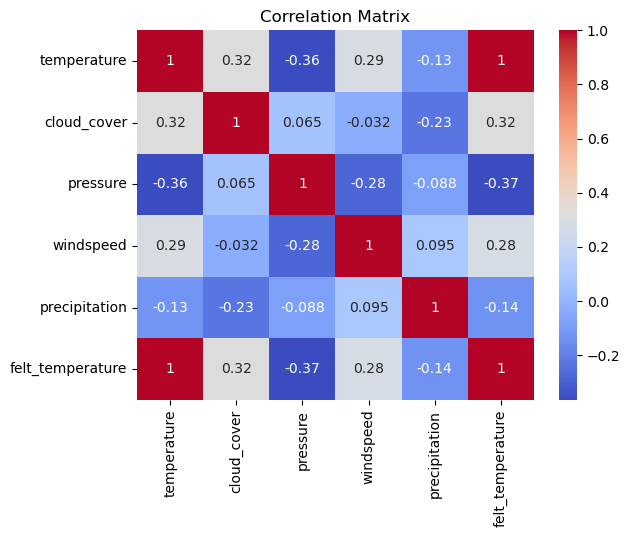

In [22]:
#check for correlation
numeric_columns = weather.select_dtypes(include=['float64'])
correlation_matrix = numeric_columns .corr()
# heatmap for correlation
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [23]:
#Temperature and felt temperature are highly correlated, so we will drop the felt temperature column
weather = weather.drop(columns=['felt_temperature'])

In [24]:
weather.head()

,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation
0,2018-01-01 08:53:00,9.0,33.0,Fair,991.75,9.0,0.0
1,2018-01-01 09:53:00,9.0,33.0,Fair,992.08,0.0,0.0
2,2018-01-01 10:53:00,9.0,21.0,Haze,992.08,0.0,0.0
3,2018-01-01 11:53:00,9.0,29.0,Partly Cloudy,992.08,0.0,0.0
4,2018-01-01 12:53:00,8.0,33.0,Fair,992.08,0.0,0.0


In [25]:
weather.to_csv('processed_data_weather.csv', index=False)